Keshia-Lee Martin<br>
DX602 - Programming Toolkit for Data Science<br>
Final Project<br>
4/26/2026

<h2>Bike Rental Demand Analysis</h2>

**Introduction**

The purpose of this project is to complete an exploratory data analytics on a data set, answering questions I'd like to investigate. The dataset I've selected is Outdoor Recreation. This dataset analyzes bike rental patterns due to the season, month, and weekday. 

From this dataset, Here are some possible questions that could be answered:

1. Which season has the highest number of bike rentals?
2. Which day of the week has the highest number of bike rentals?
3. Which weather category has the least amount of riders?
4. How do casual renters and registered renters differ?
5. How do the bike rentals change based on the traditional workdays versus the weekends?
6. What hour of the day has the most riders? 
7. What month and year has the most riders?
8. Are the bikes ridden more by the casual riders or the registered riders?

**Load and Inspecting the Data**

Pandas, numpy, matplotlib, and sklearn libraries will be used for the analysis.

In [444]:
# shared imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn.linear_model
plt.close("all")

The data set is loaded in and reviewed by displaying 10 random samples. This helps to see how the data is organized, how it's formatted, and what columns and categories can be cleaned up or name changed.

In [445]:
# loading the dataset
bikes = pd.read_csv("bikes_final.csv")

# displaying 10 sample rows
bikes.sample(10)

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,day_of_week
6863,2012-04-04 07:00:00,2,0,1,2,18.04,21.970,62,0.0000,12,354,366,Wednesday
3749,2011-09-07 04:00:00,3,0,1,3,22.96,26.515,94,11.0014,0,4,4,Wednesday
8316,2012-07-07 21:00:00,3,0,0,1,36.08,39.395,37,12.9980,51,150,201,Saturday
5904,2012-02-02 05:00:00,1,0,1,3,16.40,20.455,82,0.0000,0,19,19,Thursday
7692,2012-05-19 21:00:00,2,0,0,1,26.24,31.060,50,0.0000,81,178,259,Saturday
2707,2011-07-01 17:00:00,3,0,1,1,33.62,34.850,21,12.9980,99,362,461,Friday
924,2011-03-02 23:00:00,1,0,1,1,10.66,10.605,30,35.0008,0,22,22,Wednesday
1987,2011-05-09 17:00:00,2,0,1,1,25.42,31.060,38,16.9979,59,539,598,Monday
8358,2012-07-09 15:00:00,3,0,1,2,31.16,34.090,45,15.0013,66,214,280,Monday
5832,2012-01-18 05:00:00,1,0,1,1,13.94,14.395,46,35.0008,0,29,29,Wednesday


Our column names are:
1. datetime - hourly date and the timestamp
2. season - seasons of the year, 1 = spring, 2 = summer, 3 = fall, 4 = winter 
3. holiday - whether the day is considered a holiday
4. workingday - whether the day is neither a weekend nor holiday
5. weather  - 
    1: Clear, Few clouds, Partly cloudy, Partly cloudy, 2: Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist, 3: Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds, 4: Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog 
6. temp - temperature in Celsius
7. atemp - "feels like" temperature in Celsius
8. humidity - relative humidity
9. windspeed - wind speed
10. casual - number of non-registered user rentals
11. registered - number of registered user rentals
12. count - number of total rentals
13. day_of_week - days of the week

In [446]:
# checking columns
bikes.columns

Index(['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp',
       'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count',
       'day_of_week'],
      dtype='object')

The datatypes in our dataset are objects, integers, and floats.

In [447]:
# checking data types
bikes.dtypes

datetime        object
season           int64
holiday          int64
workingday       int64
weather          int64
temp           float64
atemp          float64
humidity         int64
windspeed      float64
casual           int64
registered       int64
count            int64
day_of_week     object
dtype: object

This dataset does not have any missing values.

In [448]:
# checking missing values
bikes.isna().any().any()


np.False_

In [449]:
bikes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   datetime     10886 non-null  object 
 1   season       10886 non-null  int64  
 2   holiday      10886 non-null  int64  
 3   workingday   10886 non-null  int64  
 4   weather      10886 non-null  int64  
 5   temp         10886 non-null  float64
 6   atemp        10886 non-null  float64
 7   humidity     10886 non-null  int64  
 8   windspeed    10886 non-null  float64
 9   casual       10886 non-null  int64  
 10  registered   10886 non-null  int64  
 11  count        10886 non-null  int64  
 12  day_of_week  10886 non-null  object 
dtypes: float64(3), int64(8), object(2)
memory usage: 1.1+ MB


**Data Cleaning and Preparation**

Creating a cleaned version of the data will improve the data analysis, making it easier to understand and read.

The datetime column is converted and separated into new columns by the hour, month, and year to do time analysis. The remapping will only be done for the month and year.


In [450]:
# converting the date column to pandas datetime
bikes["datetime"] = pd.to_datetime(bikes["datetime"])

# creating new columns that will be month, year, and hour
bikes["year"] = bikes["datetime"].dt.year.astype("category")
bikes["month"] = bikes["datetime"].dt.month.astype("category")
bikes["hour"] = bikes["datetime"].dt.hour.astype("category")

# remapping 'month' column to categorical
month_name = {
  1: "January",
  2: "February",
  3: "March",
  4: "April",
  5: "May",
  6: "June",
  7: "July",
  8: "August",
  9: "September",
  10: "October",
  11: "November",
  12: 'December'
}

bikes["month"] = bikes["month"].map(month_name)

#  remapping 'hour' column to categorical
hour_name = {
  0: "12am",
  1: "1am",
  2: "2am",
  3: "3am",
  4: "4am",
  5: "5am",
  6: "6am",
  7: "7am",
  8: "8am",
  9: "9am",
  10: "10am",
  11: "11am",
  12: "12pm",
  13:"1pm",
  14:"2pm",
  15:"3pm",
  16:"4pm",
  17:"5pm",
  18:"6pm",
  19:"7pm",
  20:"8pm",
  21:"9pm",
  22:"10pm",
  23:"11pm"
}

bikes["hour"] = bikes["hour"].map(hour_name)

# loading and view the table to make sure the columns are appearing as intended.
bikes

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,day_of_week,year,month,hour
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16,Saturday,2011,January,12am
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40,Saturday,2011,January,1am
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32,Saturday,2011,January,2am
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,3,10,13,Saturday,2011,January,3am
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,0,1,1,Saturday,2011,January,4am
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10881,2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336,Wednesday,2012,December,7pm
10882,2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241,Wednesday,2012,December,8pm
10883,2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168,Wednesday,2012,December,9pm
10884,2012-12-19 22:00:00,4,0,1,1,13.94,17.425,61,6.0032,12,117,129,Wednesday,2012,December,10pm


The seasons are remapped from the numbers to their categorical names, with the type being changed to categorical.


In [451]:
# remapping of season 1, 2, 3, 4 to spring, summer, fall, and winter
season_name = {
  1: "Spring",
  2: "Summer",
  3: "Fall",
  4: "Winter"
}

# needs to be changed from an integer to a category
bikes["season"] = bikes["season"].map(season_name).astype("category")

# to check mapping change
bikes

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,day_of_week,year,month,hour
0,2011-01-01 00:00:00,Spring,0,0,1,9.84,14.395,81,0.0000,3,13,16,Saturday,2011,January,12am
1,2011-01-01 01:00:00,Spring,0,0,1,9.02,13.635,80,0.0000,8,32,40,Saturday,2011,January,1am
2,2011-01-01 02:00:00,Spring,0,0,1,9.02,13.635,80,0.0000,5,27,32,Saturday,2011,January,2am
3,2011-01-01 03:00:00,Spring,0,0,1,9.84,14.395,75,0.0000,3,10,13,Saturday,2011,January,3am
4,2011-01-01 04:00:00,Spring,0,0,1,9.84,14.395,75,0.0000,0,1,1,Saturday,2011,January,4am
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10881,2012-12-19 19:00:00,Winter,0,1,1,15.58,19.695,50,26.0027,7,329,336,Wednesday,2012,December,7pm
10882,2012-12-19 20:00:00,Winter,0,1,1,14.76,17.425,57,15.0013,10,231,241,Wednesday,2012,December,8pm
10883,2012-12-19 21:00:00,Winter,0,1,1,13.94,15.910,61,15.0013,4,164,168,Wednesday,2012,December,9pm
10884,2012-12-19 22:00:00,Winter,0,1,1,13.94,17.425,61,6.0032,12,117,129,Wednesday,2012,December,10pm


The weather conditions are remapped from the numbers to their categorical names, with the type being changed to categorical.

In [452]:
# remapping of weather 1, 2, 3, 4 to weather condition categories
weather_name = {
  1: "Clear, Few clouds, Partly cloudy",
  2: "Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist",
  3: "Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds",
  4: "Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog"
}

# needs to be changed from an integer to a category
bikes["weather"] = bikes["weather"].map(weather_name).astype("category")

# to check mapping change
bikes

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,day_of_week,year,month,hour
0,2011-01-01 00:00:00,Spring,0,0,"Clear, Few clouds, Partly cloudy",9.84,14.395,81,0.0000,3,13,16,Saturday,2011,January,12am
1,2011-01-01 01:00:00,Spring,0,0,"Clear, Few clouds, Partly cloudy",9.02,13.635,80,0.0000,8,32,40,Saturday,2011,January,1am
2,2011-01-01 02:00:00,Spring,0,0,"Clear, Few clouds, Partly cloudy",9.02,13.635,80,0.0000,5,27,32,Saturday,2011,January,2am
3,2011-01-01 03:00:00,Spring,0,0,"Clear, Few clouds, Partly cloudy",9.84,14.395,75,0.0000,3,10,13,Saturday,2011,January,3am
4,2011-01-01 04:00:00,Spring,0,0,"Clear, Few clouds, Partly cloudy",9.84,14.395,75,0.0000,0,1,1,Saturday,2011,January,4am
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10881,2012-12-19 19:00:00,Winter,0,1,"Clear, Few clouds, Partly cloudy",15.58,19.695,50,26.0027,7,329,336,Wednesday,2012,December,7pm
10882,2012-12-19 20:00:00,Winter,0,1,"Clear, Few clouds, Partly cloudy",14.76,17.425,57,15.0013,10,231,241,Wednesday,2012,December,8pm
10883,2012-12-19 21:00:00,Winter,0,1,"Clear, Few clouds, Partly cloudy",13.94,15.910,61,15.0013,4,164,168,Wednesday,2012,December,9pm
10884,2012-12-19 22:00:00,Winter,0,1,"Clear, Few clouds, Partly cloudy",13.94,17.425,61,6.0032,12,117,129,Wednesday,2012,December,10pm


Changing the day_of_week column to categorical, but also changing the order to be Monday-Sunday, not Saturday-Friday.

In [453]:
# changing day of week type to category and reordering them from S-F to M-S
week_order = ["Monday",
  "Tuesday",
  "Wednesday",
  "Thursday",
  "Friday",
  "Saturday",
  "Sunday"]
  
bikes["day_of_week"] = pd.Categorical(bikes["day_of_week"], categories=week_order, ordered=True)

# verification that the new order and categories are correct
bikes["day_of_week"].unique()


['Saturday', 'Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
Categories (7, object): ['Monday' < 'Tuesday' < 'Wednesday' < 'Thursday' < 'Friday' < 'Saturday' < 'Sunday']

The holiday and workingday is changed from numerical to categorical strings and types.

In [454]:
#changing numerical to categorical for the holiday column
holiday_name = {
  0: "Not a Holiday",
  1: "Holiday"
}

bikes["holiday"] = bikes["holiday"].map(holiday_name).astype("category")

bikes

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,day_of_week,year,month,hour
0,2011-01-01 00:00:00,Spring,Not a Holiday,0,"Clear, Few clouds, Partly cloudy",9.84,14.395,81,0.0000,3,13,16,Saturday,2011,January,12am
1,2011-01-01 01:00:00,Spring,Not a Holiday,0,"Clear, Few clouds, Partly cloudy",9.02,13.635,80,0.0000,8,32,40,Saturday,2011,January,1am
2,2011-01-01 02:00:00,Spring,Not a Holiday,0,"Clear, Few clouds, Partly cloudy",9.02,13.635,80,0.0000,5,27,32,Saturday,2011,January,2am
3,2011-01-01 03:00:00,Spring,Not a Holiday,0,"Clear, Few clouds, Partly cloudy",9.84,14.395,75,0.0000,3,10,13,Saturday,2011,January,3am
4,2011-01-01 04:00:00,Spring,Not a Holiday,0,"Clear, Few clouds, Partly cloudy",9.84,14.395,75,0.0000,0,1,1,Saturday,2011,January,4am
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10881,2012-12-19 19:00:00,Winter,Not a Holiday,1,"Clear, Few clouds, Partly cloudy",15.58,19.695,50,26.0027,7,329,336,Wednesday,2012,December,7pm
10882,2012-12-19 20:00:00,Winter,Not a Holiday,1,"Clear, Few clouds, Partly cloudy",14.76,17.425,57,15.0013,10,231,241,Wednesday,2012,December,8pm
10883,2012-12-19 21:00:00,Winter,Not a Holiday,1,"Clear, Few clouds, Partly cloudy",13.94,15.910,61,15.0013,4,164,168,Wednesday,2012,December,9pm
10884,2012-12-19 22:00:00,Winter,Not a Holiday,1,"Clear, Few clouds, Partly cloudy",13.94,17.425,61,6.0032,12,117,129,Wednesday,2012,December,10pm


In [455]:
# changing numerical to categorical for the working day column
workingday_name = {
  0: "Not a Workday",
  1: "Workday"
}

bikes["workingday"] = bikes["workingday"].map(workingday_name).astype("category")

# verification that all columns have been updated as intended
bikes

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,day_of_week,year,month,hour
0,2011-01-01 00:00:00,Spring,Not a Holiday,Not a Workday,"Clear, Few clouds, Partly cloudy",9.84,14.395,81,0.0000,3,13,16,Saturday,2011,January,12am
1,2011-01-01 01:00:00,Spring,Not a Holiday,Not a Workday,"Clear, Few clouds, Partly cloudy",9.02,13.635,80,0.0000,8,32,40,Saturday,2011,January,1am
2,2011-01-01 02:00:00,Spring,Not a Holiday,Not a Workday,"Clear, Few clouds, Partly cloudy",9.02,13.635,80,0.0000,5,27,32,Saturday,2011,January,2am
3,2011-01-01 03:00:00,Spring,Not a Holiday,Not a Workday,"Clear, Few clouds, Partly cloudy",9.84,14.395,75,0.0000,3,10,13,Saturday,2011,January,3am
4,2011-01-01 04:00:00,Spring,Not a Holiday,Not a Workday,"Clear, Few clouds, Partly cloudy",9.84,14.395,75,0.0000,0,1,1,Saturday,2011,January,4am
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10881,2012-12-19 19:00:00,Winter,Not a Holiday,Workday,"Clear, Few clouds, Partly cloudy",15.58,19.695,50,26.0027,7,329,336,Wednesday,2012,December,7pm
10882,2012-12-19 20:00:00,Winter,Not a Holiday,Workday,"Clear, Few clouds, Partly cloudy",14.76,17.425,57,15.0013,10,231,241,Wednesday,2012,December,8pm
10883,2012-12-19 21:00:00,Winter,Not a Holiday,Workday,"Clear, Few clouds, Partly cloudy",13.94,15.910,61,15.0013,4,164,168,Wednesday,2012,December,9pm
10884,2012-12-19 22:00:00,Winter,Not a Holiday,Workday,"Clear, Few clouds, Partly cloudy",13.94,17.425,61,6.0032,12,117,129,Wednesday,2012,December,10pm


**Descriptive Statistics**

Summarizing the statistics for numerical columns and the categorical columns.

There are 7 numerical columns. They are temp, atemp, humidity, windspeed, casual, registered, and count. There are 10,886 lines of data and as noted before, no data values are missing.

In [456]:
# descriptive statistics for numerical columns
summary_numerical = bikes.describe(include="number")
summary_numerical

,temp,atemp,humidity,windspeed,casual,registered,count
count,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
std,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454
min,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000
max,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000


There are 9 categorical columns. They are season, holiday, workingday, weather, day_of_week, year, month, hour, and weekend_weekday. There are 10,886 lines of data and as noted before, no data values are missing.

Using this table, it's confirmed that the correct number of seasons, days of the week, months, and hours are in the data. It's also verifies that the data is appearing and has been cleaned up as intended by looking at holiday and weekend_weekday. For weekend_weekday, there are more weekdays than weekends. For holiday, there are more days without holidays than there are with.

In [457]:
# summary for categorical columns - excluding month, day, hour, from separately printed 
print(bikes["season"].value_counts())
print()
print(bikes["holiday"].value_counts())
print()
print(bikes["workingday"].value_counts())
print()
print(bikes["weather"].value_counts())
print()
print(bikes["day_of_week"].value_counts())
print()
print(bikes["year"].value_counts())


summary_categorical = bikes.describe(include="category")
summary_categorical

season
Winter    2734
Fall      2733
Summer    2733
Spring    2686
Name: count, dtype: int64

holiday
Not a Holiday    10575
Holiday            311
Name: count, dtype: int64

workingday
Workday          7412
Not a Workday    3474
Name: count, dtype: int64

weather
Clear, Few clouds, Partly cloudy                                                           7192
Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist                               2834
Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds     859
Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog                                    1
Name: count, dtype: int64

day_of_week
Saturday     1584
Sunday       1579
Thursday     1553
Monday       1551
Wednesday    1551
Tuesday      1539
Friday       1529
Name: count, dtype: int64

year
2012    5464
2011    5422
Name: count, dtype: int64


,season,holiday,workingday,weather,day_of_week,year,month,hour
count,10886,10886,10886,10886,10886,10886,10886,10886
unique,4,2,2,4,7,2,12,24
top,Winter,Not a Holiday,Workday,"Clear, Few clouds, Partly cloudy",Saturday,2012,May,12pm
freq,2734,10575,7412,7192,1584,5464,912,456


**Numeric Data Visualizations**

Creating histograms that show the distribution of numerical data for temp, atemp, humidity, windspeed, casual, registered, and count.

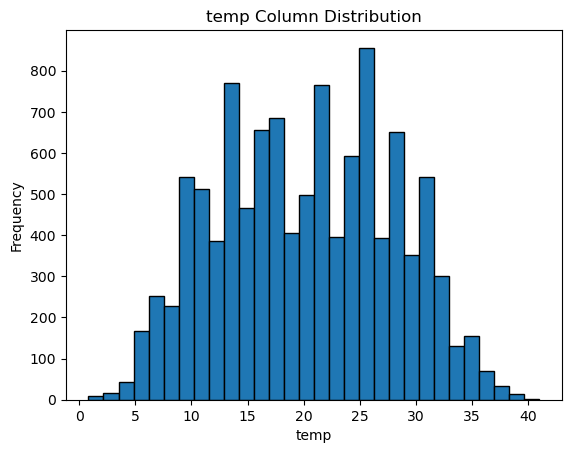

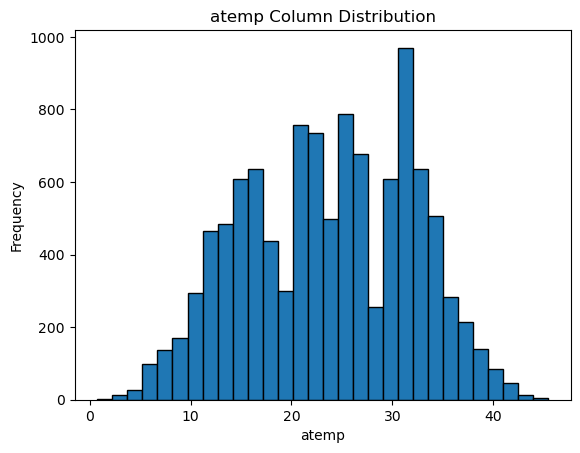

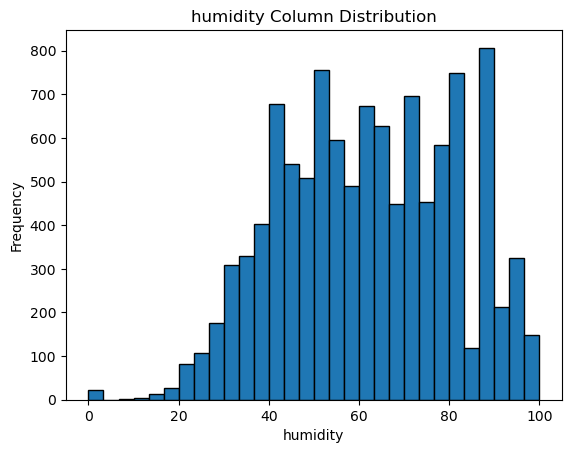

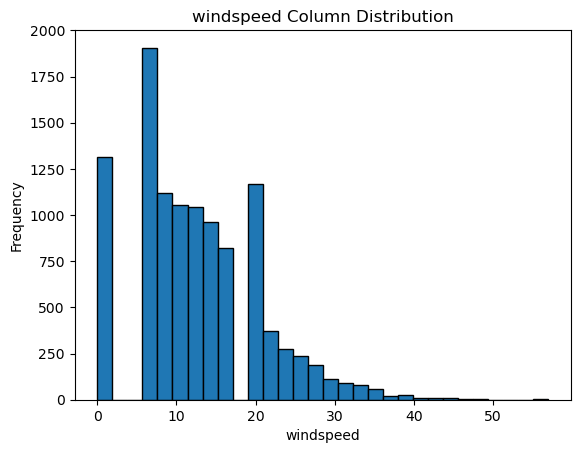

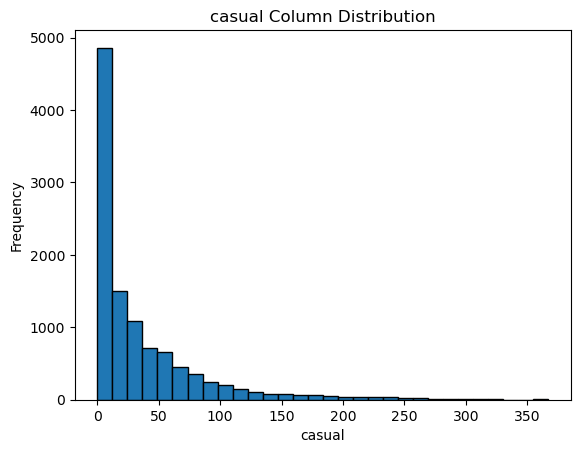

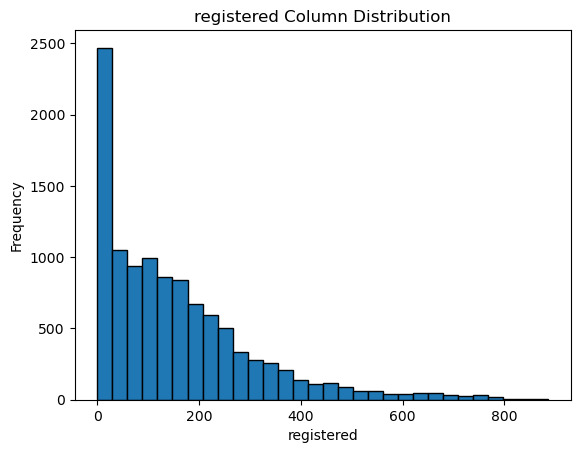

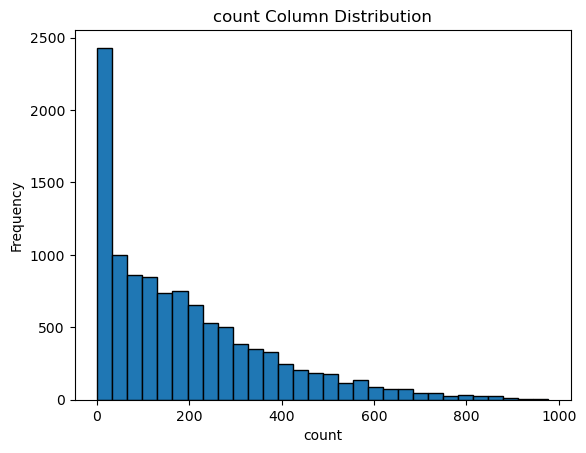

In [458]:
# created a list for all of the numerical columns
columns_numerical = [
  "temp", 
  "atemp", 
  "humidity", 
  "windspeed",
  "casual",
  "registered",
  "count"
]

# for loop to plot each of the column histograms to analyze its distribution
for column in columns_numerical:
  plt.hist(bikes[column], edgecolor="black", bins=30)
  plt.title(f"{column} Column Distribution")
  plt.xlabel(f"{column}")
  plt.ylabel("Frequency")
  plt.show()




1. The temperature (temp) histogram shows a fairly normal distribution with most of the recorded days being between roughly 8 and 32 dregrees.
2. The "feels like" temperature (atemp) histogram looks simiar to the tempurature histogram, but is shifted higher.
3. The humidity distribution is left-skewed, most of the records being between roughly 30 and 90 humidity levels.
4. The windspeed distribution is right-skewed, with most of the records falling below 20. Looking at the histogram, there are some visible outliers.
5. The non-registered (casual) users distribution is right-skewed, with most records having a number below 50 of non-registered riders. Looking at the histogram, there are some visible outliers.
6. The registered users distribution is also right-skewed, with most records having below 200 of reigistered riders. Looking at the histogram, there are some visible outliers.
7. The total bike rental count (count) distribution is right-skewed, showing that high rental days aren't as common. Looking at the histogram, there are some visible outliers.

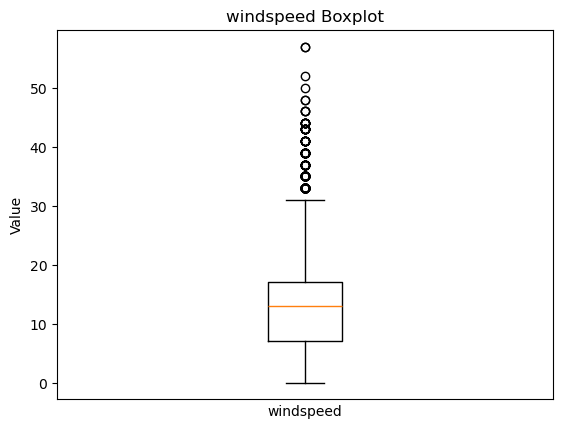

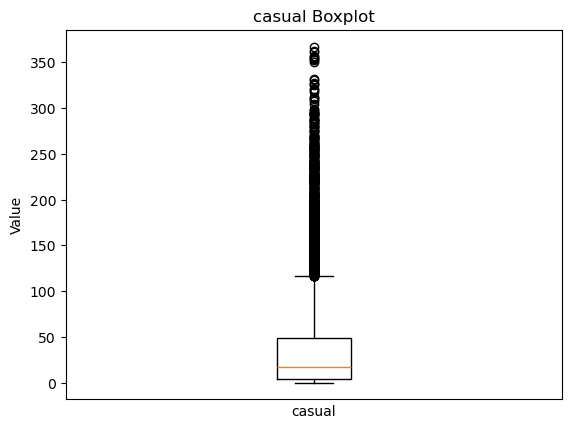

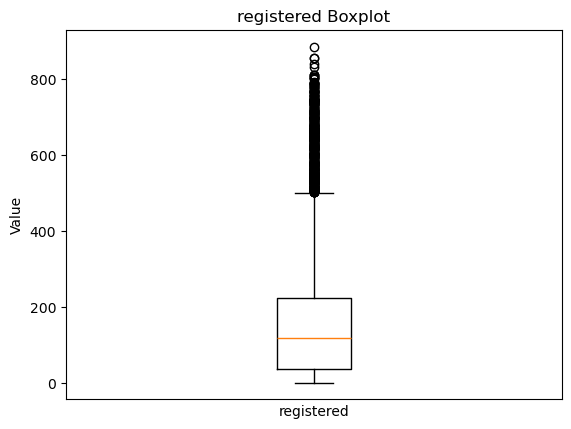

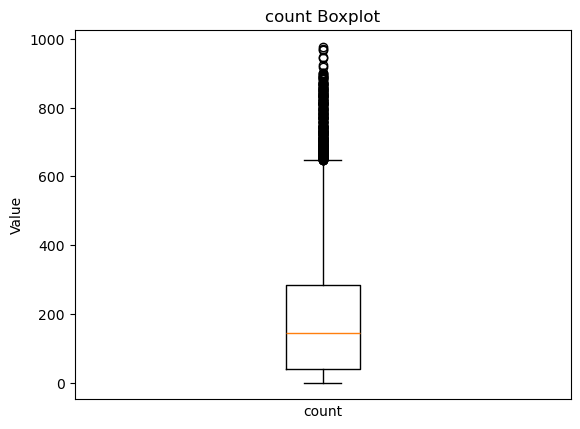

In [459]:
# created a list for all of the numerical columns for the outlier columns
columns_numerical = [
  "windspeed",
  "casual",
  "registered",
  "count"
]

# for loop to plot each of the column histograms to analyze its distribution
for column in columns_numerical:
  plt.boxplot(bikes[column])
  plt.title(f"{column} Boxplot")
  plt.xlabel(f"{column}")
  plt.ylabel("Value")
  plt.xticks([])
  plt.show()

Boxplots were done for the windspeed, count columns. From the graphs, the potential outliers are visible.


**Categorical Data Analysis**

For the categorical analysis, pie charts were created for season, holiday, workingday, weather, day_of_week, year, month, hour, and weekend_weekday, displaying the information as percentages.

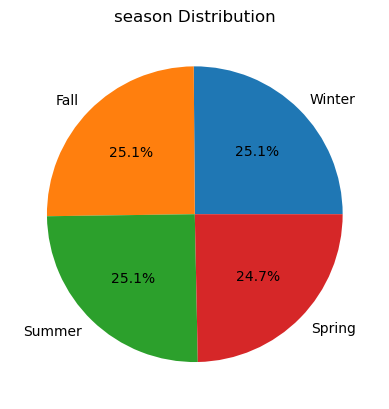

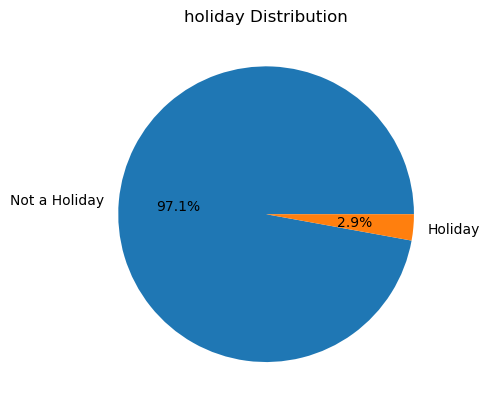

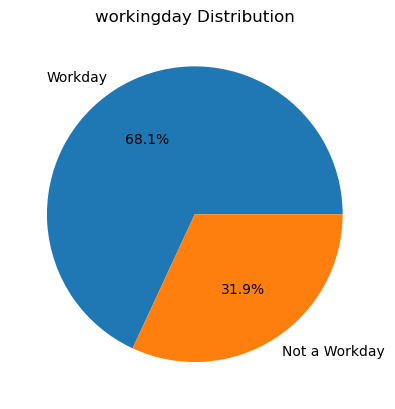

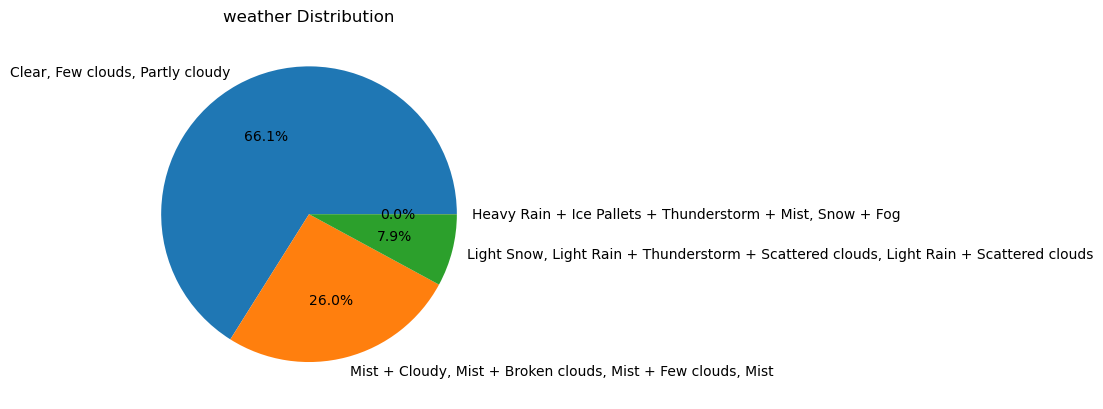

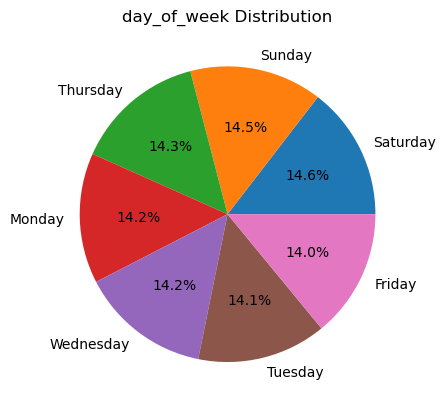

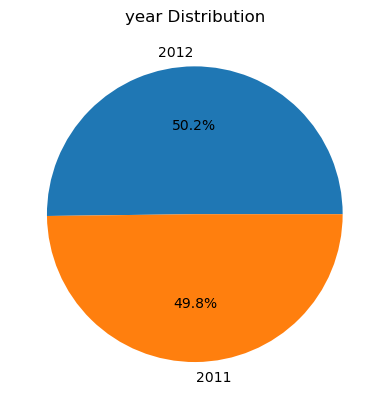

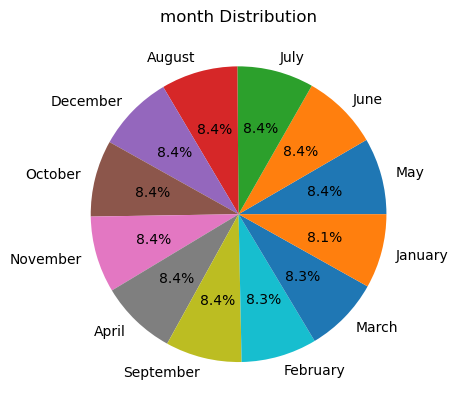

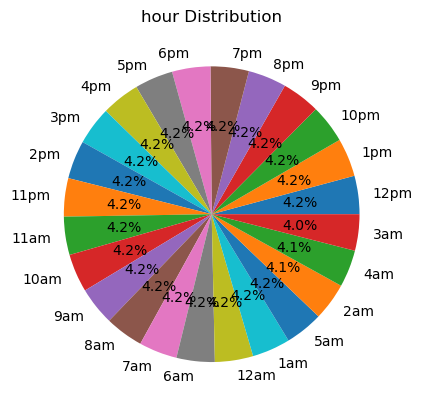

In [460]:
# list for season, holiday, workingday, weather, day_of_week, year, month, hour, and weekend_weekday
columns_categorical = [
  "season",
  "holiday",
  "workingday",
  "weather",
  "day_of_week",
  "year",
  "month",
  "hour"
]

# for loop to display all pie charts for all of the categorical columns
for column in columns_categorical:
  bikes[column].value_counts().plot(kind="pie", autopct="%1.1f%%")
  plt.title(f"{column} Distribution")
  plt.ylabel("")
  plt.show()

**Grouped Analysis**

For the grouped analysis, the data will be season and looking at the casual renters, the registered renters, and the total amount of renters for that specific season.

In [461]:
# creating a variable to group by the season category
rentals_season = bikes.groupby("season")[["casual", "registered", "count"]].sum()
rentals_season

C:\Users\19143\AppData\Local\Temp\ipykernel_24320\4145237380.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rentals_season = bikes.groupby("season")[["casual", "registered", "count"]].sum()


,casual,registered,count
season,,,
Fall,142718,497944,640662
Spring,41605,270893,312498
Summer,129672,458610,588282
Winter,78140,465894,544034


In [462]:
season_stats = bikes.groupby("season")[["casual", "registered", "count"]].describe()
season_stats

C:\Users\19143\AppData\Local\Temp\ipykernel_24320\1778592143.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  season_stats = bikes.groupby("season")[["casual", "registered", "count"]].describe()


casual                                                     registered  \
         count       mean        std  min   25%   50%   75%    max      count   
season                                                                          
Fall    2733.0  52.220271  54.638059  0.0  10.0  36.0  74.0  350.0     2733.0   
Spring  2686.0  15.489576  31.222498  0.0   1.0   5.0  15.0  367.0     2686.0   
Summer  2733.0  47.446762  57.649556  0.0   8.0  29.0  63.0  361.0     2733.0   
Winter  2734.0  28.580834  42.596214  0.0   4.0  14.0  33.0  362.0     2734.0   

                    ...                  count                               \
              mean  ...     75%    max   count        mean         std  min   
season              ...                                                       
Fall    182.196853  ...  252.00  886.0  2733.0  234.417124  197.151001  1.0   
Spring  100.853686  ...  141.00  681.0  2686.0  116.343261  125.273974  1.0   
Summer  167.804610  ...  243.00  782.0  2733.0  215.251372  192.007843  1.0   
Winter  170.407462  ...  238.75  857.0  2734.0  198.988296  177.622409  1.0   

                                   
         25%    50%    75%    max  
season                             
Fall    68.0  195.0  347.0  977.0  
Spring  24.0   78.0  164.0  801.0  
Summer  49.0  172.0  321.0  873.0  
Winter  51.0  161.0  294.0  948.0  

[4 rows x 24 columns]

Based on the information about and the bar graph below, we now know the following:

1. Fall has the most total bike rentals, for both casual and registered bike renters.
2. Spring has the least amount of total bike rentals, for both casual and registered bike renters. 

For Spring to have the lowest amount of bike rentals is interesting, as it tends to be warmer than the winter. But, weather can come into play with more rain and storms in the transition into Summer.


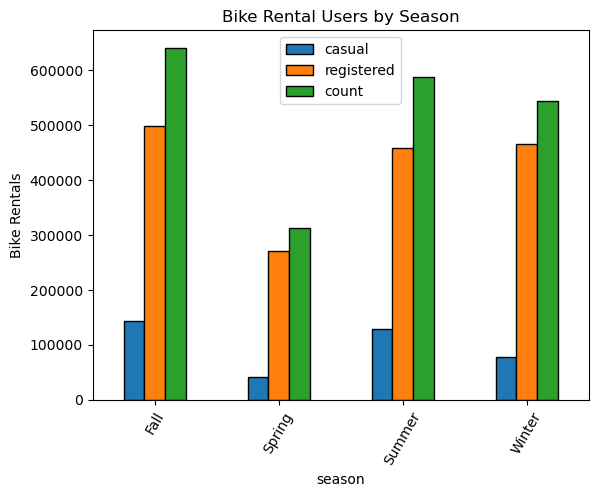

In [463]:
# bar graph
rentals_season.plot(kind="bar", edgecolor="black")
plt.title("Bike Rental Users by Season")
plt.ylabel("Bike Rentals")
plt.xticks(rotation=60)
plt.show()

**New Feature Engineering**

I created a new column for rush hour for the hours 7am-9am and 4pm-6pm. This can be used to determine the number of bike rentals by casual and registered renters, as well as the total. It's convienent to see the differences if there are in fact more rentals during those hours.

In [ ]:
# creating a column for rush hour for am 7am-9am, evening 4pm-6pm
bikes["rush_hour"] = np.where(bikes["hour"].isin(["7am", "8am", "9am", "4pm", "5pm", "6pm"]), "Rush Hour", "Not Rush Hour")
bikes["rush_hour"] = bikes["rush_hour"].astype("category")

# verifying that the column is appearing as intended
# bikes.sample(10)
# bikes.dtypes

datetime       datetime64[ns]
season               category
holiday              category
workingday           category
weather              category
temp                  float64
atemp                 float64
humidity                int64
windspeed             float64
casual                  int64
registered              int64
count                   int64
day_of_week          category
year                 category
month                category
hour                 category
rush_hour            category
dtype: object

**Section 9: Trends Over Time**

* Plot one or more time-based trends
* Include standardized values if useful for comparison
* Use line charts to illustrate trends over time
* Use standardized values when appropriate so multiple variables can be compared on the same scale

For the grouped analysis, the data will be grouped by the hour of the day, looking at casual renters, the registered renters, and the total amount of renters for that specific hour. this could also be used to look at the traditional morning and evening rush hours.

**Section 10: Variable Relationships**

* Compute correlation or covariance
* Make scatter plots
* Discuss possible relationships

* Investigate possible relationships between features
* Use:
    * Correlation or covariance statistics
    * Scatter plots

**Section 11: Hypothesis**

* State your hypothesis about a relationship in the data

**Section 12: Linear Regression**

* Select features and outcome variable
* Train the regression model
* Display predictions vs. actual values
* Plot the regression line
* Interpret results

Use `sklearn` to build a **linear regression model** that attempts to explain a relationship between one outcome variable and one or more features.

Your regression section must include:

* A clear choice of predictor variable(s)
* A clear outcome variable
* Model fitting using `LinearRegression`
* A plot showing predicted values compared to actual values
* A regression line

**11. Regression Discussion**

Briefly explain:

* What the regression results suggest
* Whether the model does a good job explaining the relationship
* Any limitations of the model


**Section 13: Reflection / Conclusion**

* Summarize your findings
* Explain what you learned
* Mention limitations and possible future improvements

<h2>**13. Something New**</h2>

You must learn and apply **at least one skill that goes beyond class examples and homework**.

Examples might include:

* A new pandas technique
* A more advanced matplotlib customization
* A new type of grouping or transformation
* A more polished plot layout

**12. Code Quality and Reuse**

Identify repetitive parts of your code and simplify them using:

* Helper functions
* Loops
* Reusable code blocks